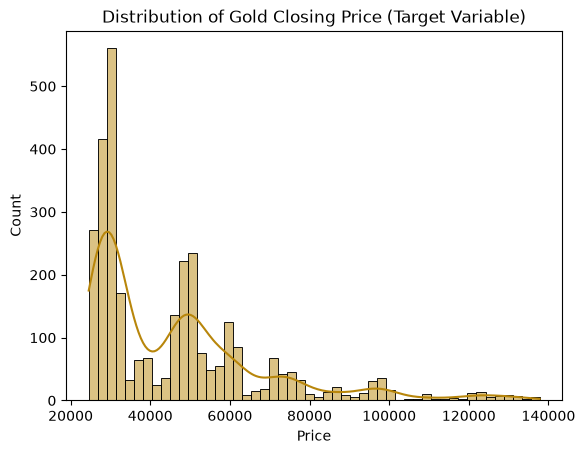

<class 'TypeError'>: 'NoneType' object is not callable

In [25]:
# Import libraries
#!mamba install pandas
##!mamba install numpy
#!mamba install seaborn
#!mamba install scikit-learn
#Undo only if using system has no direct installs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Display all columns
pd.set_option('display.max_columns', None)

# Read the CSV file
df = pd.read_csv('Gold Price.csv')
# Convert date format
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date (ensure correct chronological order)
df = df.sort_values('Date').reset_index(drop=True)


sns.histplot(df ['Price'], kde=True, bins=50, color='#B8860B')
plt.title('Distribution of Gold Closing Price (Target Variable)')
plt.xlabel('Price')
plt.show()(figsize=(15,5))
plt.plot(df['Date'], df ['Price'], color='#888608')
plt.title('Gold Closing Price Over Time (2014-2026)')
plt.xlabel('Date')
plt.ylabel('Price (Target Variable)')
plt.show()







df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Quarter'] = df['Date'].dt.quarter

df['Target'] = df['Price'].shift(-1)  # Predicting tomorrow's price
df['Return'] = df['Price'].pct_change()  # Predicting tomorrow's price

for lag in [1, 2, 3, 5, 10]:
    df[f'Price_Lag_{lag}'] = df['Price'].shift(lag)
    df[f'Volume_Lag_{lag}'] = df['Volume'].shift(lag)
    df[f'Return_Lag_{lag}'] = df['Return'].shift(lag)
for window in [3, 5, 10]:
    df[f'MA_{window}'] = df['Price'].rolling(window=window).mean()
    df[f'Std_{window}'] = df['Price'].rolling(window=window).std()
df['Daily_Range'] = df['High'] - df['Low']
df['Daily_Range_Pct'] = (df['High'] - df['Low']) / df['Low'] * 100
df['Price_Open_Ratio'] = df['Price'] / df['Open']
lo = df["Daily_Range_Pct"].quantile(0.25)
hi = df["Daily_Range_Pct"].quantile(0.75)
inter = hi - lo
lbound = lo - (inter * 1.5)
hbound = hi + (inter * 1.5)
out = df[(df["Daily_Range_Pct"] > hbound) | (df["Daily_Range_Pct"] < lbound)]
out_by_year = out.copy()
out_by_year['Year'] = pd.to_datetime(out_by_year['Date']).dt.year

df['Is_Extreme_Day'] = ((df['Daily_Range_Pct'] > hbound) |
                         (df['Daily_Range_Pct'] < lbound)).astype(int)

df_clean = df.dropna()
x = np.arange(len(df_clean)).reshape(-1, 1)
y = df_clean['Price'].values
poly = PolynomialFeatures(degree=4)
x_poly = poly.fit_transform(x)
trend_model = LinearRegression()
trend_model.fit(x_poly, y)
trend = trend_model.predict(x_poly)
df_clean['Trend'] = trend
df_clean['DPrice'] = df_clean['Price'] - df_clean['Trend']

plt.figure(figsize=(14, 6))

plt.plot(
    df_clean['Date'],
    df_clean['DPrice']
)
plt.plot(
    df_clean['Date'],
    df_clean['Trend']
)

plt.axhline(0, linestyle='--')

plt.xlabel('Date')
plt.ylabel('Detrended Price')
plt.title('Detrended Gold Price')
plt.grid(True)
plt.show()
##Now replace everything
for lag in [1, 2, 3, 5, 10]:
    df_clean[f'Price_Lag_{lag}'] = df_clean['DPrice'].shift(lag)
for window in [3, 5, 10]:
    df_clean[f'MA_{window}'] = df_clean['DPrice'].rolling(window=window).mean()
    df_clean[f'Std_{window}'] = df_clean['DPrice'].rolling(window=window).std()
df_clean = df_clean.dropna()
df_clean = df_clean.reset_index(drop=True)
df_clean.to_csv('Gold_Price_Cleaned.csv', index=False)
feature_cols=['Price_Lag_1','Price_Lag_2','Price_Lag_3',
                     'MA_3','MA_5','MA_10',
                     'Return_Lag_1','Return_Lag_2',
                     'Return_Lag_3','Return_Lag_5']
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
k = MLPRegressor(
    hidden_layer_sizes=(11,),
    max_iter=20,
    early_stopping = True,
    random_state=42
)#testing with one hidden layer
f = df_clean.loc[:,df_clean.columns != 'Date']#clear date to make training possible
f['logPrice'] = np.log(f.Price)
f['logOpen'] = np.log(f.Open)
X = f.loc[:len(f)-2,feature_cols]#Use future derived values instead so It could predict even without prior knowedle
Y = f.loc[1:,'DPrice']
YPeek = f.loc[1:,'Price']
YT = f.loc[1:,'Trend']
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42,shuffle=False)
practice,trainer, y_trend, y_probably = train_test_split(df_clean.Date[1:],
                                                         YT, test_size=0.2, random_state=42,shuffle=False)
k.fit(X_train,y_train)

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import joblib

##k=joblib.load("Neural.pkl")
isitf = k.predict(X)
isitf = isitf + YT
maef = mean_absolute_error(YPeek,isitf)
msef = mean_squared_error(YPeek, isitf)
rmsef = np.sqrt(msef)
r2f = r2_score(YPeek, isitf)
plt.figure(figsize=(12, 6))
plt.plot(df_clean.loc[1:,'Date'], YPeek.values, label="Actual Price", linewidth=1.5)
plt.plot(df_clean.loc[1:,'Date'], isitf, label="Predicted Price",
          linewidth=1.5, alpha=0.7)
plt.title("Multi Layer Perceptron: Actual vs Predicted Gold Price (Full Set)")

plt.title("Multi Layer Perceptron: Actual vs Predicted Gold Price (Full Set)")
plt.xlabel("Date")
plt.ylabel("Price (Indian Rupees)")
plt.legend()
plt.savefig("full.png", dpi=150)
plt.show()

isit = k.predict(X_test)
isit = isit+y_probably
mae = mean_absolute_error(y_test+y_probably,isit)
mse = mean_squared_error(y_test+y_probably, isit)
rmse = np.sqrt(mse)
r2 = r2_score(y_test+y_probably, isit)
plt.figure(figsize=(12, 6))
plt.plot(trainer.values, isit, label="Predicted Price",
          linewidth=1.5, alpha=0.7)
plt.plot(trainer.values, (y_test.values+y_probably.values), label="Actual Price", linewidth=1.5)
plt.title("Multi Layer Perceptron: Actual vs Predicted Gold Price (Test Set)")
plt.xlabel("Date")
plt.ylabel("Price (Indian Rupees)")
plt.legend()
plt.savefig("result.png", dpi=150)
plt.show()
full_residuals = YPeek- isitf
residuals = y_test +y_probably- isit
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
axes[0,0].scatter(YPeek, isitf, alpha=0.4, s=12, color='#1f77b4')
lims = [min(YPeek.min(), isitf.min()), max(YPeek.max(), isitf.max())]
axes[0,0].plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')
axes[0,0].set_title(f'Training set: Actual vs Predicted (R2={r2f:.4f})')
axes[0,0].set_xlabel('Actual Price'); axes[0,0].set_ylabel('Predicted Price')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
axes[0,1].scatter((y_test+y_probably), isit, alpha=0.4, s=12, color='#2ca02c')
lims = [min((y_test+y_probably).min(), isit.min()), max((y_test+y_probably).max(), isit.max())]
axes[0,1].plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')
axes[0,1].set_title(f'Testing set: Actual vs Predicted (R2={r2:.4f})')
axes[0,1].set_xlabel('Actual Price'); axes[0,1].set_ylabel('Predicted Price')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
axes[1,0].scatter(isitf, full_residuals, alpha=0.4, s=12, color='#1f77b4')
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_title('Train Residuals'); axes[1,0].set_xlabel('Predicted Price'); axes[1,0].set_ylabel('Residual')
axes[1,0].grid(alpha=0.3)
axes[1,1].scatter(isit, residuals, alpha=0.4, s=12, color='#2ca02c')
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_title('Test Residuals'); axes[1,1].set_xlabel('Predicted Price'); axes[1,1].set_ylabel('Residual')
axes[1,1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_overall_plot.png', dpi=200)
plt.show()
##Predicting stuff
rng = np.random.default_rng(42)
fture = pd.DataFrame({
    'Date': pd.date_range(start='2026-01-02', end='2026-08-31')
})
price = list(df_clean['Price'])
dprice = list(df_clean['DPrice'])
retrn = list(df_clean['Return'])
fture['Year'] = fture['Date'].dt.year
fture['Month'] = fture['Date'].dt.month
fture['Day'] = fture['Date'].dt.day
future = fture.loc[:,fture.columns != 'Date']#clear date to make training possible
future_x = np.arange(
    len(df_clean) + len(future)
).reshape(-1, 1)

future_x_poly = poly.transform(future_x)
Trending = trend_model.predict(future_x_poly)
df_clean['Trend'] = Trending[:len(df_clean)]
future['Trend'] = Trending[len(df_clean):]
for i in range(len(future)):
    future.at[i, 'Price_Lag_1'] = dprice[-1]
    future.at[i, 'Price_Lag_2'] = dprice[-2]
    future.at[i, 'Price_Lag_3'] = dprice[-3]
    future.at[i, 'Price_Lag_5'] = dprice[-5]

    future.at[i, 'MA_3'] = np.mean(dprice[-3:])
    future.at[i, 'MA_5'] = np.mean(dprice[-5:])
    future.at[i, 'MA_10'] = np.mean(dprice[-10:])
    
    future.at[i, 'Return_Lag_1'] = retrn[-1]
    future.at[i, 'Return_Lag_2'] = retrn[-2]
    future.at[i, 'Return_Lag_3'] = retrn[-3]
    future.at[i, 'Return_Lag_5'] = retrn[-5]

    # One-row input in the SAME column order as training
    test = future.loc[[i], [
        'Price_Lag_1', 'Price_Lag_2', 'Price_Lag_3', 
        'MA_3', 'MA_5', 'MA_10',
        'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5',
    ]]
    d = k.predict(test)[0] + (rng.choice(residuals))
    n = d+future.at[i,'Trend'] 
    r = (n-price[-1])/price[-1]
    future.at[i, 'DPrice'] = d
    future.at[i, 'Price'] = n
    future.at[i, 'Return'] = r
    #If I don't do this it can't be automated
    dprice.append(d)
    price.append(n)
    retrn.append(r)
future['Date'] = fture['Date']
future = future[df_clean.columns.intersection(future.columns)]
combined = pd.concat(
    [df_clean, future],
    ignore_index=True
)
plt.plot(trainer.values, isit, label="Predicted Price",
          linewidth=1.5, alpha=0.7)
plt.plot(trainer.values, (y_test.values+y_probably.values), label="Actual Price", linewidth=1.5)
plt.plot(
    future['Date'],
    future['Price'],
    label="Forecasted Price"
)
plt.title("Multi Layer Perceptron: Actual vs Predicted Gold Price (plus forecast Full set)")
plt.xlabel("Date")
plt.ylabel("Price (Indian Rupees)")
plt.legend()
plt.savefig("forecast.png", dpi=150)
plt.show()
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_validate, GridSearchCV
df_test = df.dropna(subset=feature_cols + ['Target']).reset_index(drop=True)
df_test['TimeIndex'] = np.arange(len(df_test))

X_A = df_test[feature_cols]
y_A = df_test['Target']

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_A, y_A, test_size=0.2, shuffle=False)
idx_train_A, idx_test_A = train_test_split(df_test['TimeIndex'], test_size=0.2, shuffle=False)

log_price_train = np.log(y_train_A.values)
t_train = idx_train_A.values.reshape(-1, 1)
t_test = idx_test_A.values.reshape(-1, 1)

trend_lin = LinearRegression().fit(t_train, log_price_train)
trend_quad = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(t_train, log_price_train)
r2_lin = r2_score(log_price_train, trend_lin.predict(t_train))
r2_quad = r2_score(log_price_train, trend_quad.predict(t_train))
use_quad = r2_quad > r2_lin
trend_model = trend_quad if use_quad else trend_lin

log_trend_train = trend_model.predict(t_train)
log_trend_test = trend_model.predict(t_test)
target_detrended_train = log_price_train - log_trend_train
target_detrended_test = np.log(y_test_A.values) - log_trend_test


scaler_X_A = StandardScaler().fit(X_train_A)
X_train_A_scaled = scaler_X_A.transform(X_train_A)
X_test_A_scaled = scaler_X_A.transform(X_test_A)

scaler_y_A = StandardScaler().fit(target_detrended_train.reshape(-1, 1))
target_detrended_train_scaled = scaler_y_A.transform(target_detrended_train.reshape(-1, 1)).ravel()


eval_mlp = MLPRegressor(
    hidden_layer_sizes=(11,),
    max_iter=20,
    early_stopping = True,
    random_state=42
)
eval_mlp.fit(X_train_A_scaled, target_detrended_train_scaled)

pred_detrended_train_scaled = eval_mlp.predict(X_train_A_scaled)
pred_detrended_test_scaled = eval_mlp.predict(X_test_A_scaled)
pred_detrended_train = scaler_y_A.inverse_transform(pred_detrended_train_scaled.reshape(-1, 1)).ravel()
pred_detrended_test = scaler_y_A.inverse_transform(pred_detrended_test_scaled.reshape(-1, 1)).ravel()

pred_price_train = np.exp(pred_detrended_train + log_trend_train)
pred_price_test = np.exp(pred_detrended_test + log_trend_test)

def metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

train_mse, train_rmse, train_mae, train_r2 = metrics(y_train_A, pred_price_train, "BASELINE-TRAIN")
test_mse, test_rmse, test_mae, test_r2 = metrics(y_test_A, pred_price_test, "BASELINE-TEST")
naive_test_r2 = r2_score(y_test_A, np.exp(log_trend_test))

# ============================================================
# NAIVE PERSISTENCE BASELINE (predict tomorrow = today's closing price)
# ============================================================
naive_pred_train_A = df_test.loc[X_train_A.index, 'Price'].values
naive_pred_test_A = df_test.loc[X_test_A.index, 'Price'].values
naive_mse_tr_A, naive_rmse_tr_A, naive_mae_tr_A, naive_r2_tr_A = metrics(y_train_A, naive_pred_train_A, "NAIVE-TRAIN")
naive_mse_te_A, naive_rmse_te_A, naive_mae_te_A, naive_r2_te_A = metrics(y_test_A, naive_pred_test_A, "NAIVE-TEST")

# ============================================================
# 5-FOLD TIME SERIES CROSS-VALIDATION (BASELINE HYPERPARAMS)
# ============================================================
tscv = TimeSeriesSplit(n_splits=5)
cv_pipeline = make_pipeline(StandardScaler(), MLPRegressor(
    hidden_layer_sizes=(11,),
    max_iter=20,
    early_stopping = True,
    random_state=42
))
cv_results = cross_validate(
    cv_pipeline,
    X_train_A, target_detrended_train,
    cv=tscv,
    scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
    return_train_score=False,
)

cv_r2 = cv_results["test_r2"]
cv_rmse = -cv_results["test_rmse"]
# ============================================================
# HYPERPARAMETER TUNING (GridSearchCV)
# ============================================================\
tuning_pipeline = make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(11,), max_iter=20, random_state=42))
param_grid = {
    "mlpregressor__hidden_layer_sizes": [(11,),(22,11)],
    'mlpregressor__random_state':[24,42],
    "mlpregressor__batch_size": [20,40],
}

tscv_search = TimeSeriesSplit(n_splits=3)
search_mlp = GridSearchCV(
    tuning_pipeline,
    param_grid,
    cv=tscv_search,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
search_mlp.fit(X_train_A, target_detrended_train)
tuned_mlp = search_mlp.best_estimator_

pred_detrended_train_tuned = tuned_mlp.predict(X_train_A)
pred_detrended_test_tuned = tuned_mlp.predict(X_test_A)
pred_price_train_tuned = np.exp(pred_detrended_train_tuned + log_trend_train)
pred_price_test_tuned = np.exp(pred_detrended_test_tuned + log_trend_test)

train_mse_t, train_rmse_t, train_mae_t, train_r2_t = metrics(y_train_A, pred_price_train_tuned, "TUNED-TRAIN")
test_mse_t, test_rmse_t, test_mae_t, test_r2_t = metrics(y_test_A, pred_price_test_tuned, "TUNED-TEST")

# ============================================================
# RESULT COMPARISON -- BASELINE vs TUNED vs NAIVE
# ============================================================
comparison_df_mlp = pd.DataFrame([
    {"Model": "Baseline mlp (manual params)", "Set": "Train", "MSE": train_mse, "RMSE": train_rmse, "MAE": train_mae, "R2": train_r2},
    {"Model": "Baseline mlp (manual params)", "Set": "Test", "MSE": test_mse, "RMSE": test_rmse, "MAE": test_mae, "R2": test_r2},
    {"Model": "Tuned mlp (GridSearchCV)", "Set": "Train", "MSE": train_mse_t, "RMSE": train_rmse_t, "MAE": train_mae_t, "R2": train_r2_t},
    {"Model": "Tuned mlp (GridSearchCV)", "Set": "Test", "MSE": test_mse_t, "RMSE": test_rmse_t, "MAE": test_mae_t, "R2": test_r2_t},
    {"Model": "Naive Persistence (tomorrow=today)", "Set": "Train", "MSE": naive_mse_tr_A, "RMSE": naive_rmse_tr_A, "MAE": naive_mae_tr_A, "R2": naive_r2_tr_A},
    {"Model": "Naive Persistence (tomorrow=today)", "Set": "Test", "MSE": naive_mse_te_A, "RMSE": naive_rmse_te_A, "MAE": naive_mae_te_A, "R2": naive_r2_te_A},
])
fig, ax = plt.subplots(figsize=(9, 5))
plot_df_mlp = comparison_df_mlp[comparison_df_mlp["Set"] == "Test"]
ax.bar(plot_df_mlp["Model"], plot_df_mlp["RMSE"], color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Test RMSE: Baseline vs Tuned mlp vs Naive Persistence")
ax.set_ylabel("RMSE (Price)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("mlp_baseline_vs_tuned_vs_naive_rmse.png", dpi=200)
plt.show()


